# <u>Lab Two - Classification</u>

Authors:  Muskaan Mahes, Chloe Prowse, Aayush Dalal, Nino Castellano

In [20]:
# Necessary imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## 1) <u> Data Preparation </u>

### Define and Prepare Class Variables

The Student Placement Dataset from Kaggle was collected and analyzed to determine whether students’ results were sufficient to obtain a job offer. The dataset contained over 50,000 records consisting of academic, technical, and soft-skill attributes that can influence the outcome of being placed or not. <b>(This is our primary Classification Task #1)</b> Therefore, the primary purpose of the dataset is to help students, educational institutions, career centers understand which factors are crucial for achieving a successful placement outcome. 

We previously used this data to analyze and explore the relationships between students’ key features and their placement outcome to identify important insights. We then built and evaluated two classification models (SVM and Logistic Regression) to predict a student's placement status based on various academic, technical, and personal attributes. Now our objective is to take it a step further by training and evaluating different classification models for our existing classification task, Placement Status, while also training/evaluating those same models on a different classification task we can come up with from this data.

For example, as a <b>Secondary Classification Task #2 </b> aligned with our broader goal of understanding the factors that contribute to long-term career success, we could classify a student’s likelihood of securing an internship based on their current academic, technical, and personal attributes. Predicting internship attainment is particularly meaningful because internships often serve as a critical stepping stone toward full-time employment. By modeling internship probability, we can evaluate where a student currently stands in their professional development journey and identify areas for improvement. Since even a single internship can significantly increase the likelihood of receiving a full-time offer later, this secondary task provides both practical and predictive value alongside our primary placement classification objective.

Summarizing Clasification Tasks:

- <b>Placement Outcome (Yes or No) </b>
- <b>Internship Placement (Yes or No) </b>

Together, these two classification tasks create a developmental pathway: predicting internship probability drives short-term skill adjustments that increase immediate opportunities, and those strengthened skills directly feed into improved placement outcomes, ultimately supporting long-term full-time career success.

In [21]:
#loading dataset
df = pd.read_csv("full_dataset.csv")
print(df.shape)
df.head()

(50000, 15)


,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,1048,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed
1,37820,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed
2,49668,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed
3,19467,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed
4,23094,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed


### Describe Final Dataset

Using our previously preprocessed from earlier labs which has already been cleaned, and verified to contain no missing values; the data is ready preprocessing using encoding and scaling and then for model training and testing. The only additional step required is to create a new encoded target variable, <b>Internship Placement</b>, derived from the <b>Internships</b> feature. Students with at least one internship will be labeled <b>Yes</b>, while those with none will be labeled <b>No</b>.

In [22]:
#dropping ID Because it is not useful for the model
df = df.drop(columns=["Student_ID"], errors='ignore')

# Create Internship Placement binary target variable
df["Internship_Placement"] = np.where(df["Internships"] >= 1, "Yes", "No")

#identifying numeric and categorical columns
numeric_columns = df.select_dtypes(include=[np.number]).columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Verify the identified columns
print("Numeric Columns:", len(numeric_columns))
print(numeric_columns)
print("Categorical Columns:", len(categorical_columns))
print(categorical_columns)

Numeric Columns: 10
Index(['Age', 'CGPA', 'Internships', 'Projects', 'Coding_Skills',
       'Communication_Skills', 'Aptitude_Test_Score', 'Soft_Skills_Rating',
       'Certifications', 'Backlogs'],
      dtype='object')
Categorical Columns: 5
Index(['Gender', 'Degree', 'Branch', 'Placement_Status',
       'Internship_Placement'],
      dtype='object')


In [23]:
print(df.shape)
df.head()

(50000, 15)


,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status,Internship_Placement
0,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed,No
1,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed,Yes
2,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed,Yes
3,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed,Yes
4,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed,Yes


## 2) <u> Modeling and Evaluation </u>

### Choosing and Explaining Evaluation Metrics

*Nino's Task: To Ellaborate more on Why we are using Precision for Evaluation*

### Method for Splitting Train and Test Sets

*Nino's Task: Explain the Splitting Criteria and Stratefied Fold*

In [24]:
# Encoding Placement_Status (Task 1)
le_task1 = LabelEncoder()
df["Placement_Status"] = le_task1.fit_transform(df["Placement_Status"])

# Encoding Internship_Placement (Task 2)
le_task2 = LabelEncoder()
df["Internship_Placement"] = le_task2.fit_transform(df["Internship_Placement"])

In [12]:
df.head()

,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status,Internship_Placement
0,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,0,0
1,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,0,1
2,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,0,1
3,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,1,1
4,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,1,1


In [25]:
# Getting Test and Train Split for Task 1: Placement Status Classification
X_task1 = df.drop(columns=["Placement_Status", "Internship_Placement"])
y_task1 = df["Placement_Status"]

# Identify feature types AFTER dropping targets
numeric_columns_task1 = X_task1.select_dtypes(include=np.number).columns
categorical_columns_task1 = X_task1.select_dtypes(include="object").columns

# Preprocessor for Task 1
preprocessor_task1 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns_task1),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_columns_task1)
    ]
)

# Train Test Split
X_train_task1, X_test_task1, y_train_task1, y_test_task1 = train_test_split(
    X_task1,
    y_task1,
    test_size=0.3,
    random_state=42,
    stratify=y_task1
)

# Fit ONLY on train
X_train_task1 = preprocessor_task1.fit_transform(X_train_task1)
X_test_task1 = preprocessor_task1.transform(X_test_task1)

In [26]:
# Getting Test and Train Data for Task 2: Internship Placement Classification
X_task2 = df.drop(columns=[
    "Internship_Placement", # target variable for Task 2
    "Internships",          # used to create target
    "Placement_Status"      # logically happens after internship
])

y_task2 = df["Internship_Placement"]

X_train_task2, X_test_task2, y_train_task2, y_test_task2 = train_test_split(
    X_task2, y_task2,
    test_size=0.3,
    random_state=42,
    stratify=y_task2
)

# IMPORTANT:
# Recreate column lists for Task 2 (since we dropped features)

numeric_columns_task2 = X_task2.select_dtypes(include=np.number).columns
categorical_columns_task2 = X_task2.select_dtypes(include="object").columns

preprocessor_task2 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns_task2),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_columns_task2)
    ]
)

X_train_task2 = preprocessor_task2.fit_transform(X_train_task2)
X_test_task2 = preprocessor_task2.transform(X_test_task2)

In [27]:
# Final Ready-to-Use Data
print("TASK 1 Ready Shapes:")
print(X_train_task1.shape, X_test_task1.shape)

print("\nTASK 2 Ready Shapes:")
print(X_train_task2.shape, X_test_task2.shape)

TASK 1 Ready Shapes:
(35000, 18) (15000, 18)

TASK 2 Ready Shapes:
(35000, 17) (15000, 17)


<u>Note on how to Plug and Play Test and Train Sets into Models</u>

Task 1 Train and Test Sets (Placement Status):
X_train_task1, X_test_task1, y_train_task1, y_test_task1

Task 2 Train and Test Sets (Internship Placement):
X_train_task2, X_test_task2, y_train_task2, y_test_task2

Instructions on How to Use:

1. Initialize model
2. Fit on train
3. Predict on test
4. Evaluate

Example Classifier for Task 1:

Initialize

- rf = RandomForestClassifier(random_state=42)

Train

- rf.fit(X_train_task1, y_train_task1)

Predict on test set

- y_pred_task1 = rf.predict(X_test_task1)

Evaluate

- print("Accuracy:", accuracy_score(y_test_task1, y_pred_task1))
- print(classification_report(y_test_task1, y_pred_task1))



### Three Different Classification/Regression Models

### Analyze Random Forest Model Results Using Choosen Evaluation Metric

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, classification_report

# Model for the first classification
rf_task1 = RandomForestClassifier(random_state=42)
rf_task1.fit(X_train_task1, y_train_task1)

y_pred_task1 = rf_task1.predict(X_test_task1)

precision_task1 = precision_score(y_test_task1, y_pred_task1)
print("Task 1 Precision:", precision_task1)
print("Task 1 Classification Report:")
print(classification_report(y_test_task1, y_pred_task1))


# Model for the second classification
rf_task2 = RandomForestClassifier(random_state=42)
rf_task2.fit(X_train_task2, y_train_task2)

y_pred_task2 = rf_task2.predict(X_test_task2)

precision_task2 = precision_score(y_test_task2, y_pred_task2)
print("Task 2 Precision:", precision_task2)
print("Task 2 Classification Report:")
print(classification_report(y_test_task2, y_pred_task2))
print(rf_task2.get_params())

Task 1 Precision: 1.0
Task 1 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9563
           1       1.00      1.00      1.00      5437

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000

Task 2 Precision: 0.7600887532935793
Task 2 Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.75      0.70      6886
           1       0.76      0.68      0.72      8114

    accuracy                           0.71     15000
   macro avg       0.71      0.71      0.71     15000
weighted avg       0.72      0.71      0.71     15000

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, classification_report

# Adjust parameters 

rf_task1 = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    class_weight='balanced',
    min_samples_leaf=2,
    random_state=42
)

rf_task1.fit(X_train_task1, y_train_task1)

y_pred_task1 = rf_task1.predict(X_test_task1)

precision_task1 = precision_score(y_test_task1, y_pred_task1)

print("Task 1 Precision:", precision_task1)
print("Task 1 Classification Report:")
print(classification_report(y_test_task1, y_pred_task1))


rf_task2 = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    class_weight='balanced',
    min_samples_leaf=2,
    random_state=42
)

rf_task2.fit(X_train_task2, y_train_task2)

y_pred_task2 = rf_task2.predict(X_test_task2)

precision_task2 = precision_score(y_test_task2, y_pred_task2)

print("\nTask 2 Precision:", precision_task2)
print("Task 2 Classification Report:")
print(classification_report(y_test_task2, y_pred_task2))
print(rf_task2.get_params())

Task 1 Precision: 1.0
Task 1 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9563
           1       1.00      1.00      1.00      5437

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000


Task 2 Precision: 0.8244718309859155
Task 2 Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.86      0.73      6886
           1       0.82      0.58      0.68      8114

    accuracy                           0.70     15000
   macro avg       0.73      0.72      0.70     15000
weighted avg       0.74      0.70      0.70     15000

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 15, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 

### Analyze Model Results Using Choosen Evaluation Metric For Task 1 

  In order to model the classification task for predicting whether a student receives job placement or not, a Random Forest classifier was implemented. We decided to implement a Random Forest because it builds multiple decision trees and combines those predictions to improve classification performance and reduce the chance of overfitting. We ran the model twice, adjusting several parameters to help improve the models performance. This includes the number of trees, maximum tree depth, and the minimum number of samples that are required in the leaf nodes. Also, class weighing was used to help balance the classes when training the model. Precision was the metric that was used to evaluate the model because it focuses on limiting the number of false positive predictions. The best Random Forest model achieved a test precision of 1.00, while also achieving a perfect recall and F1-scores for both of the classes. This means that the model correctly classified all of the observations in the test dataset. When examining the data, these results are likely because of the synthetic nature of the dataset. There are clear patterns that are between features and the target variables, which allows the Random Forest Model to effectively learn the relationships and classify the observations correctly.

### Analyze Model Results Using Choosen Evaluation Metric For Task 2

  In order to model the classification task for predicting whether a student will get an internship, a Random Forest model was used. The parameters were adjusted to achieve a precision score of 0.82 and an accuracy of 0.70. This means that about 82% of the students were predicted to get an internship and were correctly classified. Although, the model still produced both false positives and false negatives. The classification report shows that there is consistent performance across both classes, which means that the model is relatively balanced between precision and recall. When comparing both tasks, task 2 is more complex since the internship outcomes could depend on other factors that are not captured in this dataset. For example, things like interview performance and networking is likely not fully captured, causing it to be less precise. This model was able to identify many of the patterns in the data but it cannot perfectly separate the two classes. Although this model is not perfect in precision, the score is still strong, which indicates that it does well in identifying students who are likely to get an internship and keeps the number of false positives predictions low. 


### Visualization for Task 1

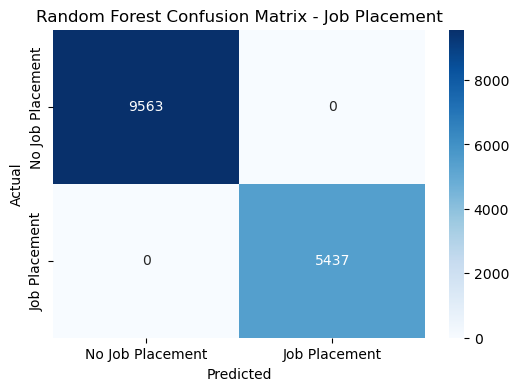

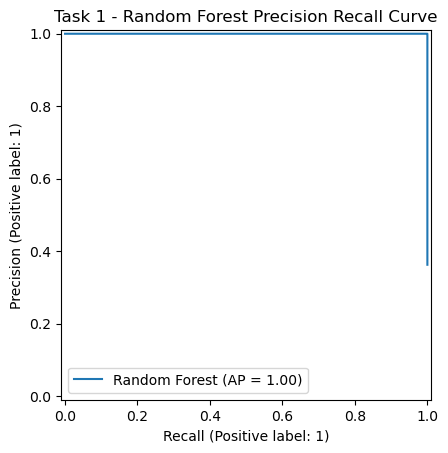

In [41]:
from sklearn.metrics import confusion_matrix, PrecisionRecallDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix for the Random Forest model job placement

y_pred_rf_task1 = rf_task1.predict(X_test_task1)

cm = confusion_matrix(y_test_task1, y_pred_rf_task1)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Job Placement","Job Placement"],
            yticklabels=["No Job Placement","Job Placement"])

plt.title("Random Forest Confusion Matrix - Job Placement")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Precision recall curve for the Random Forest model job placement

y_scores_rf_task1 = rf_task1.predict_proba(X_test_task1)[:,1]

PrecisionRecallDisplay.from_predictions(
    y_test_task1,
    y_scores_rf_task1,
    name="Random Forest"
)

plt.title("Task 1 - Random Forest Precision Recall Curve")
plt.show()

  In order to visualize the performance, a confusion matrix and a precision recall curve were created for task 1. The confusion matrix shows that the Random Forest model was able to correctly classify 9,563 students who did not get job placement and 5,437 students who did get job placement. As shown by the zeros in the purple area, there were no false positives or false negatives. This means that all of the observations were classified correctly, which confirms the metrics found earlier when the model achieved a precision, recall, and accuracy of 1.00. As mentioned above, these results are likely because of the synthetic nature of the dataset, meaning that the relationships between the features and placement outcomes are following a very distinct pattern. Since the pattern is very distinct, the model was able to classify each observation correctly. 
  The precision recall curve also shows us perfect performance, with the precision score being 1.00. Across all the levels we see a consistent 1.00, which means every time the model predicts, it predicts correctly. Overall, this model is able to separate the two classes in the dataset perfectly. 


### Visualization for Task 2

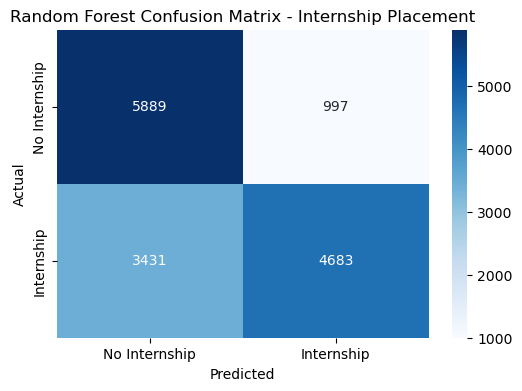

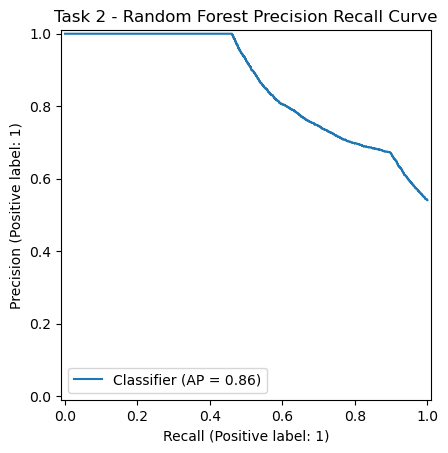

In [39]:
from sklearn.metrics import confusion_matrix, PrecisionRecallDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix for the Random Forest model internship placement 

y_pred_rf_task2 = rf_task2.predict(X_test_task2)

cm = confusion_matrix(y_test_task2, y_pred_rf_task2)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Internship","Internship"],
            yticklabels=["No Internship","Internship"])

plt.title("Random Forest Confusion Matrix - Internship Placement")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Precision recall curve for the Random Forest model internship placement 

y_scores_rf_task2 = rf_task2.predict_proba(X_test_task2)[:,1]

PrecisionRecallDisplay.from_predictions(
    y_test_task2,
    y_scores_rf_task2
)

plt.title("Task 2 - Random Forest Precision Recall Curve")
plt.show()

  In order to visualize the performance, a confusion matrix and a precision recall curve were created for task 2. The confusion matrix shows that the Random Forest model was able to correctly classify 5,889 students who did not get an internship and 4,683 students who did get an internship. However, there were also 997 false positives and 3,431 false negatives. This shows that the model is still classifying incorrectly for predictions and explains why the model got a precision score of 0.82 and an accuracy score of 0.70. 
  The precision recall curve also shows the moderate performance of the model. The curve starts out with high precision but starts to decrease when recall increases. The visualization also shows an average precision score of 0.86. This suggests that the model does well in classifying correct internship predictions, but it is unable to fully separate the two classes.

### Discuss Advantages of Each Model on Each Classification/Regression Task

 The Random Forest model showed different advantages for each of the classification tasks. In task 1, the model performed very well, achieving a perfect test precision and recall score. This would suggest that the model was able to effectively capture the patterns in the synthetic data. Since Random Forest models average the predictions across multiple trees, it helps in reducing overfitting and is able to model nonlinear relationships that are between features.
  In task 2 the performance was lower, which means that predicting internship placement is a more complex problem since the features don't perfectly separate the two classes. Although, the Random Forest model still achieved a strong precision score and had a relatively balanced performance across the two classes. Overall, the Random Forest model is able to perform well on structured data and is a great tool to capture relationships between multiple features, which is why it performed well with this dataset.

### Which Attributes are Most Important for each Classification Task

## 3) <u> Deployment </u>

### Usefulness of Model to Interested Parties 

## 4) <u> Exceptional Work </u>

### Additional Model or Hyperparameter Tuning Via Grid Search